# Statistics Final Exam: 
## Statistical Analysis of the Bullet Cluster
#### Renzo
#### Roberto
#### Thiele
#### Juan David Galan Vargas

### Libraries and Models

In [1]:
import numpy as np
import matplotlib . pyplot as plt
from scipy.optimize import minimize , curve_fit
from scipy.stats import chi2 as chi2dist , norm as normdist
from scipy.stats import t as tdist , f as fdist , kstest
from scipy.integrate import quad
import pandas as pd
import warnings
warnings.filterwarnings ("ignore")


In [2]:
# PROVIDED MODELS ---

def model_2gauss(x , A1 , mu1 , sig1 , A2 , mu2 , sig2 ):
    #" " " Two - component Gaussian profile . " " "
    return ( A1 * np . exp ( -(x - mu1 ) **2/(2* sig1 **2) ) + A2 * np . exp ( -(x - mu2 ) **2/(2* sig2 **2) ) )
def model_1gauss (x , A1 , mu1 , sig1 ) :
#" " " Single - component Gaussian profile . " " "
    return A1 * np . exp ( -(x - mu1 ) **2/(2* sig1 **2) )

def model_2beta (x , S1 , x1 , r1 , b1 , S2 , x2, r2, b2):
#" " " Two - component beta profile . " " "
    return ( S1 /(1+(( x - x1 ) / r1 ) **2) ** b1 + S2 /(1+(( x - x2 ) / r2 ) **2) ** b2 )
def model_1beta (x , S1 , x1 , r1 , b1 ) :
#" " " Single - component beta profile . " " "
    return S1 /(1+(( x - x1 ) / r1 ) **2) ** b1
#
# PHYSICAL CONSTANTS --- PROVIDED
#
arcmin_to_Mpc = 0.157 # 1 arcmin at z =0.296
M_per_gal= 2e11 # Msun per galaxy
M_per_SX= 1.5e10# Msun per X - ray count
M_per_kappa = 3e14# Msun per unit integrated kappa

### Part 0: Data

In [24]:
data=pd.read_csv("BulletClusterData.csv") #"z"
def redshift_to_arcmin(data, H0=70.0, c=299792.458, arcmin_to_Mpc=arcmin_to_Mpc):
    # Approximate distance from Hubble's law
    redshift=data["z"]
    distance_mpc = (c * redshift) / H0
    # Convert Mpc to arcminutes
    arcmin = distance_mpc / arcmin_to_Mpc
    data["Mpc"]= distance_mpc
    data["ArcMin"]= arcmin
    return data
data=redshift_to_arcmin(data)

In [25]:
data.head()

,z,Mpc,ArcMin
0,0.308657,1321.900061,8419.745612
1,0.288159,1234.114205,7860.600033
2,0.312851,1339.862586,8534.156602
3,0.698692,2992.321375,19059.371818
4,0.283483,1214.084686,7733.023479


(array([ 17.,  11., 124.,  56.,  12.,  11.,  18.,  16.,  13.,  22.]),
 array([ 37.06862616,  93.85531644, 150.64200672, 207.428697  ,
        264.21538728, 321.00207755, 377.78876783, 434.57545811,
        491.36214839, 548.14883867, 604.93552894]),
 <BarContainer object of 10 artists>)

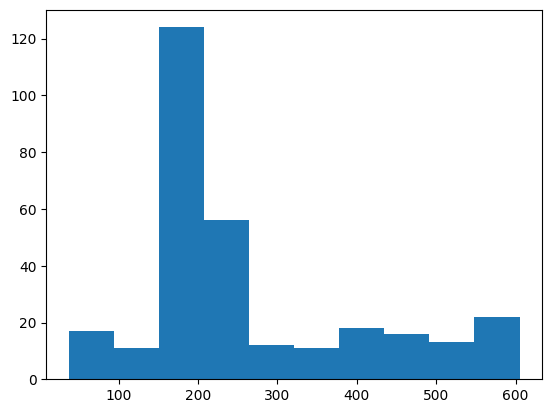

In [23]:
plt.hist(data["ArcMin"])

### Part 1: Redshift Distribution and Cluster Membership

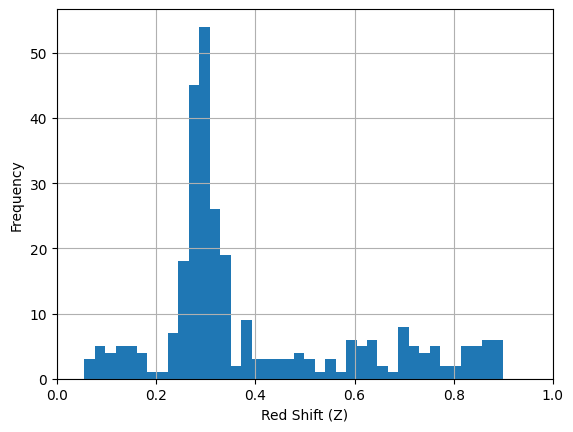

In [ ]:
# TODO 1.1 Plot the redshift histogram of z all using 40 bins over [0, 1].
# Identify the cluster peak visually. Label axes and add a title.
n, bins, patches = plt.hist(data["z"],bins=40)
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.show()
sigma_N = np.sqrt(n)
sigma_N[sigma_N == 0] = 1.0


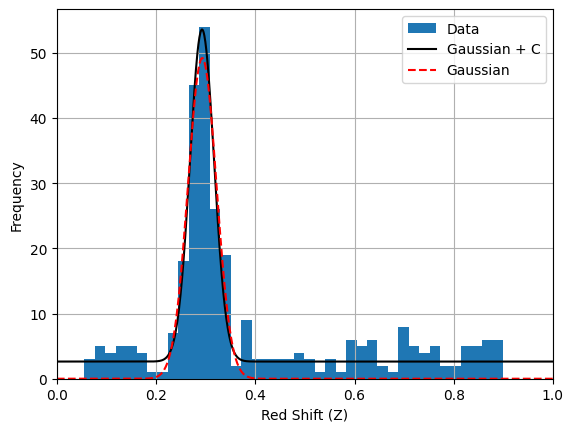

Gauss + C: Parameter: Z_cl: 0.2926034681439329 . Standar Deviation Error: 0.002688868838599602
Gauss + C: Parameter: Sigma_cl: 0.024204648846366597 . Standar Deviation Error: 0.002333877445583732
Gauss: Parameter: Z_cl: 0.2929984243771342 . Standar Deviation Error: 0.0041951862820614905
Gauss: Parameter: Sigma_cl: 0.02867633995106924 . Standar Deviation Error: 0.0031642950310759666


In [ ]:
#Fit a Gaussian+background model to the cluster peak using MLE:
bins_center = 0.5*(bins[:-1] + bins[1:])

def gaussian_plus_background(z,A,z_cl,sigma_cl,C):
    return A* np.exp((-1*(z-z_cl)**2)/(2* sigma_cl**2)) + C


x= np.linspace(0,1,1000)
initial_guess_1=[50,0.3,0.001,5]
popt_bc, pcov_bc = curve_fit(gaussian_plus_background,bins_center,n,sigma=sigma_N,maxfev=100000,p0=initial_guess_1)
popt_nobc, pcov_nobc = curve_fit(model_1gauss,bins_center,n,sigma=sigma_N,maxfev=100000,p0=initial_guess_1[:-1])

plt.hist(data["z"],bins=40, label="Data")
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.plot(x,gaussian_plus_background(x, *popt_bc),label="Gaussian + C",color="black")
plt.plot(x,model_1gauss(x,*popt_nobc),label="Gaussian",color="red",ls="--")
plt.legend()
plt.show()
perr_bc = np.sqrt(np.diag(pcov_bc))
perr_nobc = np.sqrt(np.diag(pcov_nobc))

print("Gauss + C: Parameter: Z_cl: "+str(popt_bc[1])+" . Standar Deviation Error: "+str(perr_bc[1]))
print("Gauss + C: Parameter: Sigma_cl: "+str(popt_bc[2])+" . Standar Deviation Error: "+str(perr_bc[2]))
z_bc=popt_bc[1]
sigma_bc=popt_bc[2]
z_nobc=popt_nobc[1]
sigma_nobc=popt_nobc[2]
print("Gauss: Parameter: Z_cl: "+str(popt_nobc[1])+" . Standar Deviation Error: "+str(perr_nobc[1]))
print("Gauss: Parameter: Sigma_cl: "+str(popt_nobc[2])+" . Standar Deviation Error: "+str(perr_nobc[2]))


In [ ]:
#Define cluster membership: a galaxy belongs to the cluster if |z − ẑcl| < 3σ̂cl.
#Count how many galaxies satisfy this criterion. Report the fraction of members vs. total.
sigmas=[3,2,1]
models=[[z_bc,sigma_bc],[z_nobc,sigma_nobc]]

for model in models:
    for i in sigmas:
        member_counter=0
        for j in data["z"]:
    #print(i)
            if np.abs(j - model[0]) < i*model[1]:
                member_counter+=1
        fracc=member_counter/len(data["z"])
        print("fraction of galaxies ("+str(member_counter)+") that belong to the cluster: "+str(fracc)+" for sigmas: "+str(i))

fraction of galaxies (171) that belong to the cluster: 0.57 for sigmas: 3
fraction of galaxies (160) that belong to the cluster: 0.5333333333333333 for sigmas: 2
fraction of galaxies (107) that belong to the cluster: 0.3566666666666667 for sigmas: 1
fraction of galaxies (175) that belong to the cluster: 0.5833333333333334 for sigmas: 3
fraction of galaxies (168) that belong to the cluster: 0.56 for sigmas: 2
fraction of galaxies (119) that belong to the cluster: 0.39666666666666667 for sigmas: 1


In [ ]:
#Compute χ̃2 for the Gaussian+background fit. Is the fit acceptable?
# Compare with a single Gaussian (no C) and comment on the difference. (model1_gauss)

def chi2_val(model,num_params):
    sigma = np.sqrt(n)
    sigma[sigma == 0] = 1.0
    y_fit = model#gaussian_plus_background(centers, *popt)
    chi2 = float(np.sum(((n - y_fit)/sigma)**2))
    dof = len(n) - len(num_params)
    chi2_red = chi2/dof
    return chi2_red

popt, pcov = curve_fit(gaussian_plus_background,bins_center,n)
print("Curve fit: Gaussian + Background")
print(chi2_val(gaussian_plus_background(n,*popt),popt))
popt, pcov = curve_fit(model_1gauss,bins_center,n)
print("Curve fit: Gaussian")
print(chi2_val(model_1gauss(n,*popt),popt))

guess = [
    n.max(),                     # amplitude
    bins_center[np.argmax(n)],       # mean
    np.std(data["z"]),                # sigma
    n.min()                      # background
]

def chi2(params):
    model = gaussian_plus_background(bins_center, *params)
    sigma = np.sqrt(n)
    sigma[sigma == 0] = 1.0
    return np.sum(((n - model) / sigma)**2)

result = minimize(chi2, guess)

best_params = result.x
cov = result.hess_inv
errors = np.sqrt(np.diag(cov))
print("Minimize Chi Square: Gaussian + Background")
print(chi2_val(gaussian_plus_background(n,*best_params),best_params))
print("Z_cl = "+str(best_params[1])+" Hessian STD: "+ str(errors[1]))
print("Sigma_cl = "+str(best_params[2])+" Hessian STD: "+str(errors[2]))

def chi2_nobc(params):
    model = model_1gauss(bins_center, *params)
    sigma = np.sqrt(n)
    sigma[sigma == 0] = 1.0
    return np.sum(((n - model) / sigma)**2)

guess.pop()
result = minimize(chi2_nobc, guess)

best_params = result.x
cov = result.hess_inv
errors = np.sqrt(np.diag(cov))
print("Minimize Chi Square: Gaussian")
print(chi2_val(model_1gauss(n,*best_params),best_params))
print("Z_cl = "+str(best_params[1])+" Hessian STD: "+ str(errors[1]))
print("Sigma_cl = "+str(best_params[2])+" Hessian STD: "+str(errors[2]))

del popt, pcov, guess, result, best_params, sigmas



Curve fit: Gaussian + Background
5.257361851175897
Curve fit: Gaussian
8.108108108108109
Minimize Chi Square: Gaussian + Background
4.961972455516931
Z_cl = 0.2470551750791451 Hessian STD: 0.0006251794055945299
Sigma_cl = 0.005539181108298279 Hessian STD: 0.0003522257637162884
Minimize Chi Square: Gaussian
8.108108108108109
Z_cl = 0.25923539829735387 Hessian STD: 0.005614821169107325
Sigma_cl = 0.0023786181834214437 Hessian STD: 0.0037935579453617836


### Part 2: Profile Fitting

#### Galaxy Number Density

In [ ]:
# Convert Z to arc min with: arcmin_to_Mpc = 0.157 (1 arcmin at z =0.296)


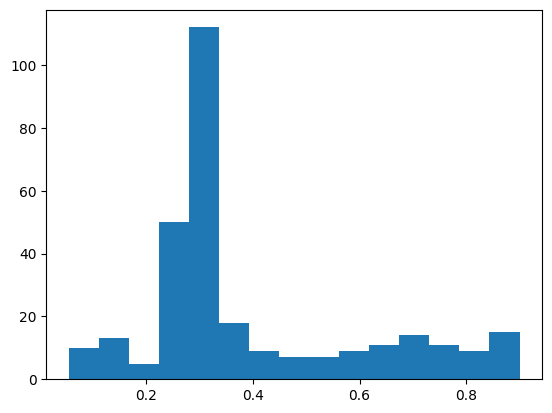

In [5]:
#Variable renaming
number_bins=15
n, bins, patches = plt.hist(data["z"],bins=number_bins)
bins_center = 0.5*(bins[:-1] + bins[1:])
bins_lenght = np.abs(bins[:-1] - bins[1:])
x_bins=bins_center
N_obs= n
sigma_N = np.sqrt(n)
sigma_N[sigma_N == 0] = 1.0

del bins_center, n


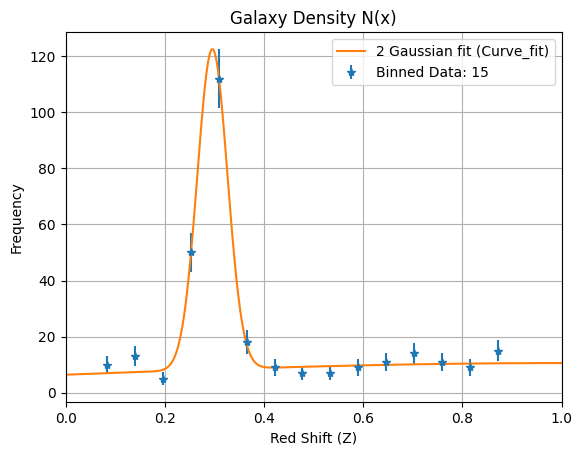

Parameter: mu1: 0.2958053314772627 . Standar Deviation Error: 0.0032997182024176305
Parameter: mu2: 0.9999999999999999 . Standar Deviation Error: 1.9875944271513808


In [6]:
#Fit model 2gauss to N obs using curve fit
# Initial guess: A1 ≈ 45, µ1 ≈ −3, σ1 ≈ 1, A2 ≈ 20, µ2 ≈ 3, σ2 ≈ 1
# Store popt N, pcov N.
#x , A1 , mu1 , sig1 , A2 , mu2 , sig2
#initial_guess=[45,-3,1,20,3,1]
initial_guess=[110,0.31,0.035,15,0.69,0.07]
#bounds=(0, [3., 1., 0.5])
#bounds=((100,120),(0,1),(0,1),(5,20),(0,1),(0,1)])
bounds=([100,0,0,5,0,0],[120,1,1,20,1,1])
x= np.linspace(0,1,1000)
popt_N, pcov_N = curve_fit(model_2gauss,x_bins,N_obs,sigma=sigma_N,p0=initial_guess,maxfev=100000,bounds=bounds)
#plt.hist(data["z"],bins=number_bins, label="Data")
plt.errorbar(x_bins,N_obs,yerr=sigma_N,fmt="*",label="Binned Data: "+str(len(x_bins)))
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.plot(x,model_2gauss(x, *popt_N),label="2 Gaussian fit (Curve_fit)")
plt.legend()
plt.title("Galaxy Density N(x)")
plt.show()
perr_N = np.sqrt(np.diag(pcov_N))
print("Parameter: mu1: "+str(popt_N[1])+" . Standar Deviation Error: "+str(perr_N[1]))
print("Parameter: mu2: "+str(popt_N[4])+" . Standar Deviation Error: "+str(perr_N[4]))
#z_cl_N=popt_N[1]
#sigma_cl_N=popt_N[2]


In [7]:
#Compute χ̃2 χ̃2min and \nu
def chi2_val(data,model,num_params):
    sigma = np.sqrt(data)
    sigma[sigma == 0] = 1.0
    y_fit = model
    chi2 = float(np.sum(((data - y_fit)/sigma)**2))
    dof = len(data) - len(num_params)
    chi2_red = chi2/dof
    return chi2_red

print(chi2_val(N_obs,model_2gauss(N_obs,*popt_N),popt_N))


33.332546284145664


In [8]:
def chi2_2gauss(params):
    return chi2_val(N_obs,model_2gauss(N_obs,*params),params)

#result = minimize(chi2_2gauss, initial_guess,method='Nelder-Mead', options={'xatol':1e-8,'fatol':1e-8,'maxiter':100000})
result = minimize(chi2_2gauss, initial_guess,method='BFGS', options={'maxiter':100000})
#result = minimize(chi2_2gauss, initial_guess,method='Powell', options={'maxiter':100000})
#result = minimize(chi2_2gauss, initial_guess,method='CG', options={'maxiter':100000})
#result = minimize(chi2_2gauss, initial_guess,method='L-BFGS-B', options={'maxiter':100000})
#result = minimize(chi2_2gauss, initial_guess,method='TNC', options={'maxiter':100000})

best_params = result.x
print("Minimized Chi Square: 2 Gaussians")
print(chi2_val(N_obs,model_2gauss(N_obs,*best_params),best_params))




Minimized Chi Square: 2 Gaussians
33.333333333333336


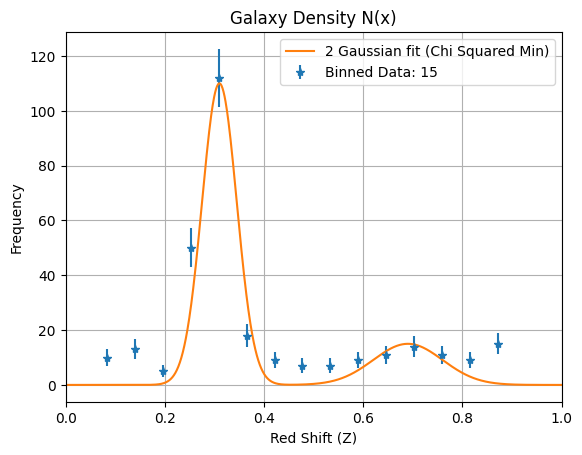

Parameter: mu1: 0.31
Parameter: mu2: 0.69


In [9]:
x= np.linspace(0,1,1000)
plt.errorbar(x_bins,N_obs,yerr=sigma_N,fmt="*",label="Binned Data: "+str(len(x_bins)))
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.plot(x,model_2gauss(x, *best_params),label="2 Gaussian fit (Chi Squared Min)")
plt.legend()
plt.title("Galaxy Density N(x)")
plt.show()
print("Parameter: mu1: "+str(best_params[1]))#+" . Standar Deviation Error: "+str(perr_N[1]))
print("Parameter: mu2: "+str(best_params[4]))

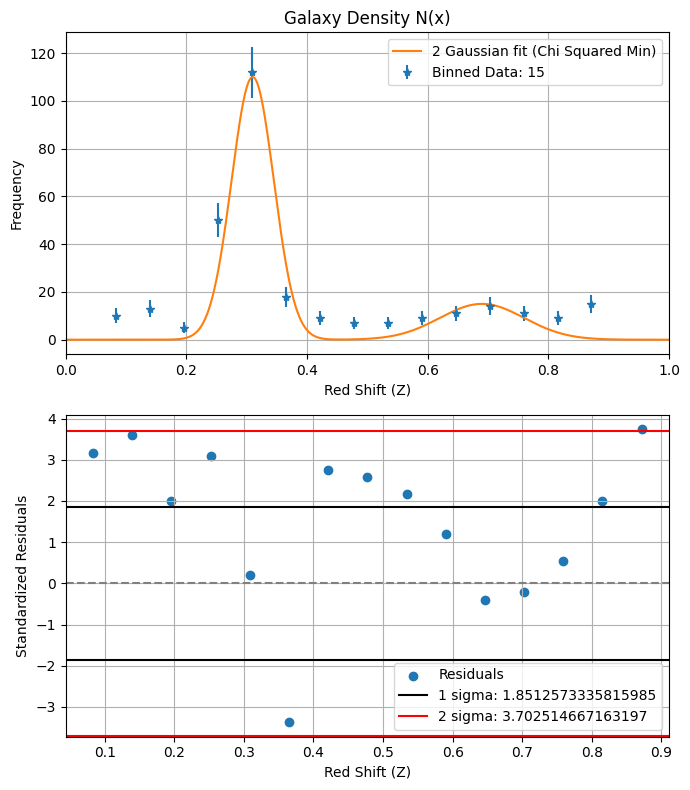

In [10]:
# 2.4: Three-panel figure
fig, axes = plt.subplots(2, 1, figsize=(7, 8))
axes[0].errorbar(x_bins,N_obs,yerr=sigma_N,fmt="*", label="Binned Data: "+str(len(x_bins)))
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Red Shift (Z)")
axes[0].set_xlim((0,1))
axes[0].grid("True")
axes[0].plot(x,model_2gauss(x, *best_params),label="2 Gaussian fit (Chi Squared Min)")
axes[0].legend()
axes[0].set_title("Galaxy Density N(x)")
axes[0].grid(True)
# Panel 2 — Residuals
#axes[1]: (mu_obs - mu_m3_fit) / sigma_i vs z
residual_N= (N_obs-model_2gauss(x_bins,*best_params))/sigma_N
axes[1].scatter(x_bins,residual_N,label="Residuals")
# Add horizontal lines at ±1, ±2 sigma
axes[1].axhline(np.std(residual_N),color="black")
axes[1].axhline(-1*np.std(residual_N),label="1 sigma: "+str(np.std(residual_N)),color="black")
axes[1].axhline(2*np.std(residual_N),color="r",label="2 sigma: "+str(2*np.std(residual_N)))
axes[1].axhline(-2*np.std(residual_N),color="r")
# Add horizontal line at 0
axes[1].axhline(0,ls="--",color="gray")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlabel("Red Shift (Z)")
axes[1].set_ylabel("Standardized Residuals")
plt.tight_layout()
#plt.savefig('part2_chi2_fit.pdf')
plt.show()

#### X-ray surface brightness

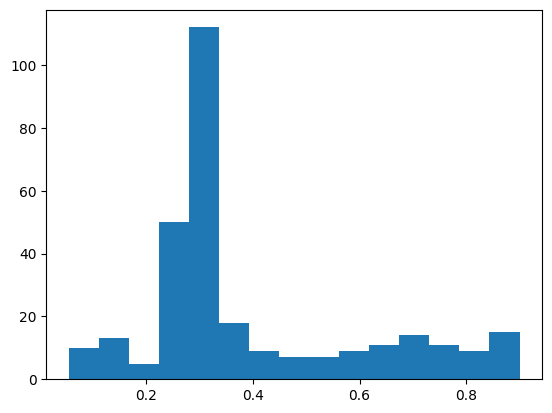

In [11]:
#Variable renaming
number_bins=15
n, bins, patches = plt.hist(data["z"],bins=number_bins)
bins_center = 0.5*(bins[:-1] + bins[1:])
bins_lenght = np.abs(bins[:-1] - bins[1:])
x_bins=bins_center
SX_obs= n
sigma_SX = np.sqrt(n)
sigma_SX[sigma_N == 0] = 1.0

del bins_center, n


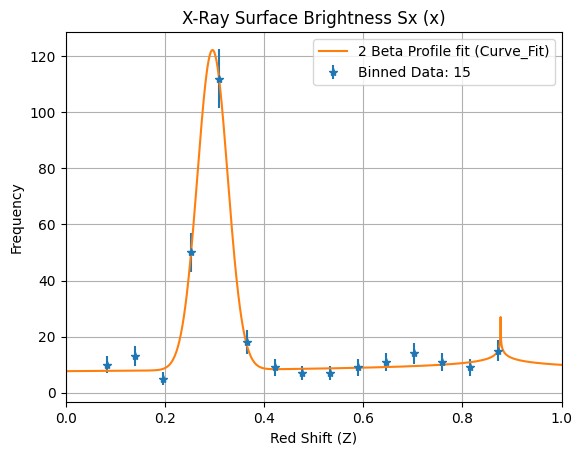

Parameter: x1: 0.29606463606023914 . Standar Deviation Error: 0.008617835516307782
Parameter: x2: 0.876935347764573 . Standar Deviation Error: 0.12086720411789019


In [12]:
#Fit model 2beta to SXobs using curve fit
# Initial guess: S1 ≈ 80, x1 ≈ −2, r1 ≈ 1.5, β1 ≈ 0.8, S2 ≈ 35, x2 ≈ 2, r2 ≈ 1.0, β2 ≈ 0.7.
#initial_guess=[80,-2,1.5,0.8,35,2,1,0.7]
initial_guess_SX=[110,0.31,0.5,80,15,0.69,1,70]
x= np.linspace(0,1,1000)
popt_SX, pcov_SX = curve_fit(model_2beta,x_bins,SX_obs,sigma=sigma_SX,p0=initial_guess_SX,maxfev=100000)
#plt.hist(data["z"],bins=number_bins, label="Data")
plt.errorbar(x_bins,SX_obs,yerr=sigma_SX,fmt="*", label="Binned Data: "+str(len(x_bins)))
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.title("X-Ray Surface Brightness Sx (x)")
plt.plot(x,model_2beta(x, *popt_SX),label="2 Beta Profile fit (Curve_Fit)")
plt.legend()
plt.show()
perr_SX = np.sqrt(np.diag(pcov_SX))
print("Parameter: x1: "+str(popt_SX[1])+" . Standar Deviation Error: "+str(perr_SX[1]))
print("Parameter: x2: "+str(popt_SX[5])+" . Standar Deviation Error: "+str(perr_SX[5]))



Chi Square Test Curve Fit:
25.976686131642545
Minimized Chi Square: 2 Beta
42.857142857142854


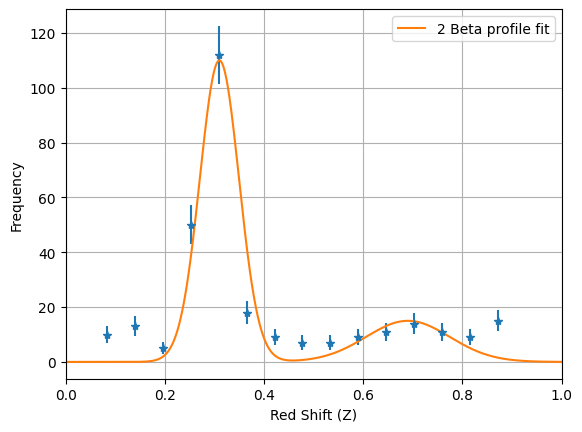

Parameter: x1: 0.31
Parameter: x2: 0.69


In [13]:
#Compute χ̃2 χ̃2min and \nu
def chi2_val(data,model,num_params):
    sigma = np.sqrt(data)
    sigma[sigma == 0] = 1.0
    y_fit = model
    chi2 = float(np.sum(((data - y_fit)/sigma)**2))
    dof = len(data) - len(num_params)
    chi2_red = chi2/dof
    return chi2_red
print("Chi Square Test Curve Fit:")
print(chi2_val(SX_obs,model_2beta(SX_obs,*popt_SX),popt_SX))

def chi2_2beta(params):
    return chi2_val(SX_obs,model_2beta(SX_obs,*params),params)

result = minimize(chi2_2beta, initial_guess_SX,method='BFGS', options={'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='Nelder-Mead', options={'xatol':1e-8,'fatol':1e-8,'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='Powell', options={'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='CG', options={'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='L-BFGS-B', options={'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='TNC', options={'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='Powell', options={'maxiter':100000})
best_params_SX = result.x
print("Minimized Chi Square: 2 Beta")
print(chi2_val(SX_obs,model_2beta(SX_obs,*best_params_SX),best_params_SX))

x= np.linspace(0,1,1000)
plt.errorbar(x_bins,SX_obs,yerr=sigma_SX,fmt="*")
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.plot(x,model_2beta(x, *best_params_SX),label="2 Beta profile fit")
plt.legend()
plt.show()
print("Parameter: x1: "+str(best_params_SX[1]))#+" . Standar Deviation Error: "+str(perr_N[1]))
print("Parameter: x2: "+str(best_params_SX[5]))


In [14]:
cov = result.hess_inv
errors = np.sqrt(np.diag(cov))
errors

array([1., 1., 1., 1., 1., 1., 1., 1.])

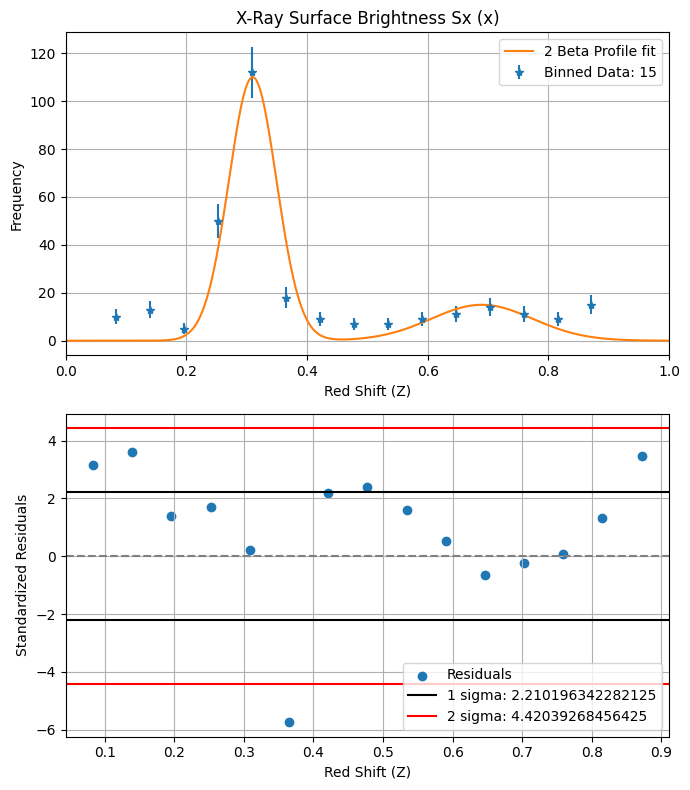

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(7, 8))
axes[0].errorbar(x_bins,SX_obs,yerr=sigma_SX,fmt="*", label="Binned Data: "+str(len(x_bins)))
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Red Shift (Z)")
axes[0].set_xlim((0,1))
axes[0].grid("True")
axes[0].plot(x,model_2beta(x, *best_params_SX),label="2 Beta Profile fit")
axes[0].legend()
axes[0].set_title("X-Ray Surface Brightness Sx (x)")
axes[0].grid(True)
# Panel 2 — Residuals
#axes[1]: (mu_obs - mu_m3_fit) / sigma_i vs z
residual_SX= (SX_obs-model_2beta(x_bins,*best_params_SX))/sigma_SX
axes[1].scatter(x_bins,residual_SX,label="Residuals")
# Add horizontal lines at ±1, ±2 sigma
axes[1].axhline(np.std(residual_SX),color="black")
axes[1].axhline(-1*np.std(residual_SX),label="1 sigma: "+str(np.std(residual_SX)),color="black")
axes[1].axhline(2*np.std(residual_SX),color="r",label="2 sigma: "+str(2*np.std(residual_SX)))
axes[1].axhline(-2*np.std(residual_SX),color="r")
# Add horizontal line at 0
axes[1].axhline(0,ls="--",color="gray")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlabel("Red Shift (Z)")
axes[1].set_ylabel("Standardized Residuals")
plt.tight_layout()
#plt.savefig('part2_chi2_fit.pdf')
plt.show()

#### Lensing Convergence

### Part 3 Residual Diagnostic
Usen los calculados en la anterior parte

### Part 4  Hypothesis Test: Dark Matter Detection


### Part 5 Mass Budget and Error Propagation